In [16]:
# 1. Instalar librerías
!pip install osmnx geopandas contextily scipy shapely matplotlib

Descargando infraestructura en un radio de 3 km...
Calculando diagramas de Voronoi...
Generando imagen final...
¡Listo! Imagen generada y guardada como 'voronoi_kennedy_seguro.png'.


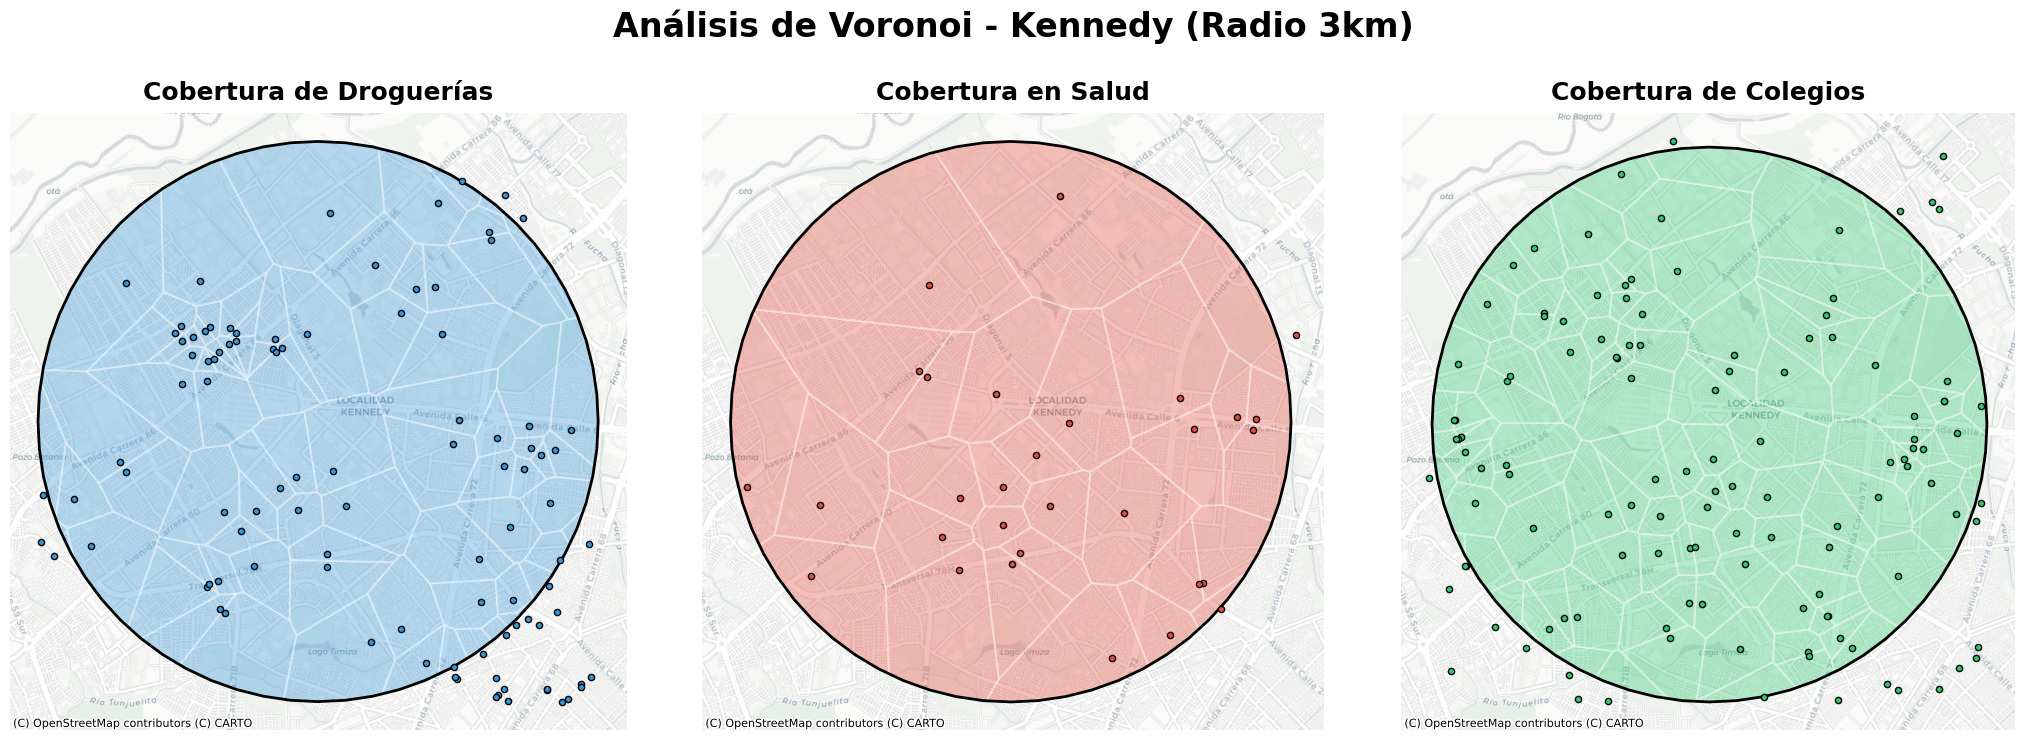

In [17]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, Point
import warnings

# Ocultar advertencias
warnings.filterwarnings('ignore')

# ==========================================
# 2. DESCARGA DE DATOS (Método seguro por radio)
# ==========================================
centro_kennedy = (4.6300, -74.1535) # (Latitud, Longitud)
radio_metros = 3000

print("Descargando infraestructura en un radio de 3 km...")
tags_droguerias = {'amenity': 'pharmacy'}
tags_salud = {'amenity': ['hospital', 'clinic', 'doctors', 'health_centre']}
tags_colegios = {'amenity': ['school', 'kindergarten']}

# Descarga garantizada sin errores de texto
droguerias = ox.features_from_point(centro_kennedy, tags=tags_droguerias, dist=radio_metros)
salud = ox.features_from_point(centro_kennedy, tags=tags_salud, dist=radio_metros)
colegios = ox.features_from_point(centro_kennedy, tags=tags_colegios, dist=radio_metros)

# ==========================================
# 3. CREACIÓN DE LA FRONTERA MATEMÁTICA
# ==========================================
# En lugar de depender de la frontera política que causa errores,
# creamos un círculo perfecto de 3km exactos para recortar el mapa.
punto_central = Point(-74.1535, 4.6300) # (Longitud, Latitud)
centro_gdf = gpd.GeoDataFrame(geometry=[punto_central], crs="EPSG:4326")

# Convertimos a formato de metros (Web Mercator 3857) y creamos el círculo (buffer)
area_estudio_3857 = gpd.GeoDataFrame(geometry=centro_gdf.to_crs(epsg=3857).buffer(radio_metros))

# Función para extraer coordenadas en formato Web Mercator (metros)
def extraer_coordenadas(gdf):
    puntos = gdf.to_crs(epsg=3857).geometry.centroid
    return np.array([[p.x, p.y] for p in puntos])

coords_droguerias = extraer_coordenadas(droguerias)
coords_salud = extraer_coordenadas(salud)
coords_colegios = extraer_coordenadas(colegios)

# ==========================================
# 4. CREACIÓN Y RECORTE DE VORONOI
# ==========================================
def crear_voronoi_recortado(coords, boundary_gdf):
    bounds = boundary_gdf.total_bounds
    dx, dy = bounds[2] - bounds[0], bounds[3] - bounds[1]

    # Puntos lejanos para cerrar los polígonos externos
    puntos_fantasma = np.array([
        [bounds[0] - 2*dx, bounds[1] - 2*dy],
        [bounds[2] + 2*dx, bounds[1] - 2*dy],
        [bounds[2] + 2*dx, bounds[3] + 2*dy],
        [bounds[0] - 2*dx, bounds[3] + 2*dy]
    ])

    todas_coords = np.vstack([coords, puntos_fantasma])
    vor = Voronoi(todas_coords)

    poligonos = []
    for region_index in vor.point_region[:len(coords)]:
        region = vor.regions[region_index]
        if -1 not in region and len(region) > 2:
            poligonos.append(Polygon([vor.vertices[i] for i in region]))
        else:
            poligonos.append(None)

    # Convertimos a tabla espacial y recortamos con nuestro círculo perfecto
    vor_gdf = gpd.GeoDataFrame(geometry=poligonos, crs=boundary_gdf.crs).dropna()
    vor_recortado = gpd.clip(vor_gdf, boundary_gdf)
    return vor_recortado

print("Calculando diagramas de Voronoi...")
vor_d = crear_voronoi_recortado(coords_droguerias, area_estudio_3857)
vor_s = crear_voronoi_recortado(coords_salud, area_estudio_3857)
vor_c = crear_voronoi_recortado(coords_colegios, area_estudio_3857)

# ==========================================
# 5. RENDERIZADO FINAL (Imagen Estática)
# ==========================================
print("Generando imagen final...")
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

def dibujar_mapa(ax, vor_gdf, coords, titulo, color):
    # 1. Polígonos de Voronoi
    vor_gdf.plot(ax=ax, facecolor=color, edgecolor='white', alpha=0.35, linewidth=1.5, zorder=2)
    # 2. Borde del área de estudio (Círculo)
    area_estudio_3857.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, zorder=3)
    # 3. Puntos exactos
    ax.scatter(coords[:, 0], coords[:, 1], c=color, s=20, edgecolor='black', zorder=4)
    # 4. Mapa base de fondo (Calles reales en estilo claro)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    ax.set_axis_off()
    ax.set_title(titulo, fontsize=18, fontweight='bold', pad=10)

# Dibujar cada panel
dibujar_mapa(axs[0], vor_d, coords_droguerias, 'Cobertura de Droguerías', '#3498db')
dibujar_mapa(axs[1], vor_s, coords_salud, 'Cobertura en Salud', '#e74c3c')
dibujar_mapa(axs[2], vor_c, coords_colegios, 'Cobertura de Colegios', '#2ecc71')

plt.suptitle("Análisis de Voronoi - Kennedy (Radio 3km)", fontsize=24, fontweight='bold', y=1.05)
plt.tight_layout()

# Guardar la imagen
plt.savefig('voronoi_kennedy_seguro.png', dpi=200, bbox_inches='tight')
print("¡Listo! Imagen generada y guardada como 'voronoi_kennedy_seguro.png'.")

# Mostrar en pantalla
plt.show()